# Большое домашнее задание 2

In [1]:
#pip install sacrebleu comet-ml

In [2]:
#!git clone https://github.com/k1ngofdarks/DL-Transformers.git

In [3]:
#!mv DL-Transformers DL_Transformers
#!ls

In [4]:
from comet_ml import Experiment
import torch

try:
    from data_utils import create_dataloaders, load_data_splits
    from modeling import TransformerModel
    from train_utils import train_model, translate_and_save
except:
    from DL_Transformers.data_utils import create_dataloaders, load_data_splits
    from DL_Transformers.modeling import TransformerModel
    from DL_Transformers.train_utils import train_model, translate_and_save


In [5]:
train_de, train_en, val_de, val_en, test_de, data_folder = load_data_splits()
print("Train size:", len(train_de))
print("Val   size:", len(val_de))
print("Test  size:", len(test_de))
print("DATA_FOLDER:", data_folder)


Train size: 195915
Val   size: 986
Test  size: 2998
DATA_FOLDER: bhw2-data/data


In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
#print(f"AMP dtype: {amp_dtype}")


device: cuda


In [7]:
BATCH_SIZE = 64
MAX_LEN = 80


de_tokenizer, en_tokenizer, train_loader, val_loader = create_dataloaders(
    train_de=train_de,
    train_en=train_en,
    val_de=val_de,
    val_en=val_en,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    size_vocab=25000,
)


In [8]:
# experiment = Experiment(
#     api_key="1kc44ZRsKlVzok3SMdIgY8E6v",
#     project_name="dl-transformers"
# )

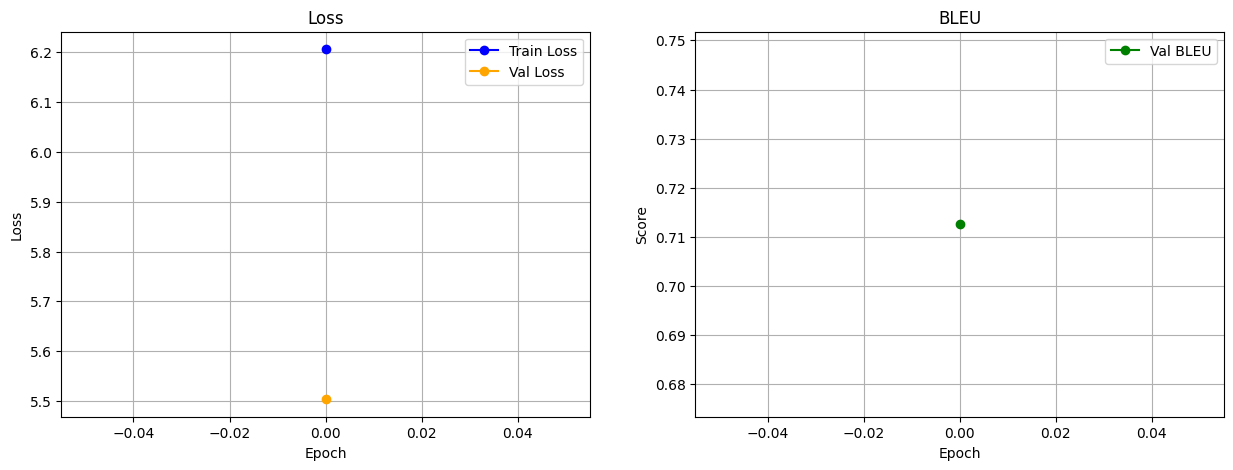

Epoch 1/15 | Train Loss: 6.2059 | Val Loss: 5.5036 | Val BLEU: 0.71 | Best BLEU: 0.71


Epoch 2/15 - train:   0%|          | 0/3062 [00:00<?, ?it/s]

DO eval


Epoch 2/15 - val:   0%|          | 0/16 [00:00<?, ?it/s]

END eval


In [ ]:
model = TransformerModel(
    src_vocab=len(de_tokenizer),
    tgt_vocab=len(en_tokenizer),
    pad_id_src=de_tokenizer.word2id["<pad>"],
    pad_id_tgt=en_tokenizer.word2id["<pad>"],
    d_model=320,
    nhead=5,
    num_encoder_layers=4,
    num_decoder_layers=4,
    dim_feedforward=1024,
    dropout=0.15,
    max_len=100,
).to(DEVICE)

train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    src_tokenizer=de_tokenizer,
    tgt_tokenizer=en_tokenizer,
    val_src_texts=val_de,
    val_tgt_texts=val_en,
    epochs=15,
    device=DEVICE,
    comet_experiment=None,
)


In [ ]:
translate_and_save(
    model=model,
    src_sentences=test_de,
    src_tokenizer=de_tokenizer,
    tgt_tokenizer=en_tokenizer,
    device=DEVICE,
    filename="translation_test1.en",
    batch_size=128,
    comet_experiment=None,
)

#experiment.end()